In [1]:
import glob
import json
import pandas as pd
from tqdm import tqdm

In [2]:
result_paths = glob.glob('./Result/analysis_reports/*')
result_paths = sorted(result_paths, key=lambda x: x.split('/')[-1])

In [3]:
df_reuslt_total = pd.DataFrame(columns=['company_name', 'date', 'calculated_score', 'average_severity', 'number_of_evidence', 'holistic_analysis'])

for f_p in result_paths:
    with open(f_p, 'r', encoding='utf-8') as f:
        result = json.load(f)[0]
    
    company_name = f_p.split('/')[-1].split('_')[0]
    date = f_p.split('/')[-1].split('_')[1].split('.')[0]
    calculated_score = result['calculated_score']
    average_severity = result['average_severity']
    holistic_analysis = result['holistic_analysis']
    evidence_list = result['evidence_list']
    number_of_evidence = len(evidence_list)
    df_reuslt_total.loc[len(df_reuslt_total)] = [company_name, date, calculated_score, average_severity, number_of_evidence, holistic_analysis]

df_reuslt_total.to_csv('./Result/llm_result/total_analysis_report.csv', index=False, encoding='utf-8-sig')
df_reuslt_total

,company_name,date,calculated_score,average_severity,number_of_evidence,holistic_analysis
0,AAPL,2021-10-29,65,3.611111,18,Apple’s 2021 Form 10-K portrays COVID-19 as a ...
1,AAPL,2022-10-28,85,4.473684,19,Apple’s 2022 Form 10-K positions COVID-19 as a...
2,AAPL,2023-11-03,10,5.000000,2,Apple’s 2023 Form 10-K continues to link the C...
3,AAPL,2024-11-01,7,3.500000,2,Apple’s 2024 Form 10-K still treats COVID-19 a...
4,ABBV,2021-02-19,28,3.111111,9,The filing was submitted less than a year afte...
...,...,...,...,...,...,...
1723,ZBRA,2024-02-15,29,3.222222,9,Zebra Technologies (ZBRA) acknowledges the COV...
1724,ZTS,2021-02-16,91,6.500000,14,Zoetis’ 2020 Form 10-K links the COVID-19 pand...
1725,ZTS,2022-02-15,63,5.727273,11,"The filing—dated February 15 2022, i.e., withi..."
1726,ZTS,2023-02-14,72,3.428571,21,Zoetis’ 2022 Form 10-K makes it clear that the...


In [4]:
df_reuslt_total['date'] = pd.to_datetime(df_reuslt_total['date'], format='%Y-%m-%d')

In [5]:
df_result_2021 = df_reuslt_total[df_reuslt_total['date'].dt.year == 2021]
df_result_2022 = df_reuslt_total[df_reuslt_total['date'].dt.year == 2022]
df_result_2023 = df_reuslt_total[df_reuslt_total['date'].dt.year == 2023]
df_result_2024 = df_reuslt_total[df_reuslt_total['date'].dt.year == 2024]

<Axes: >

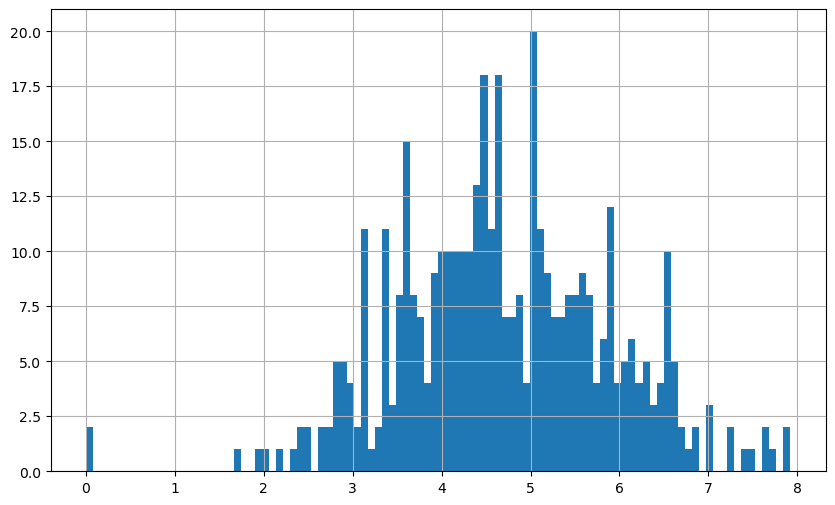

In [6]:
df_result_2021['average_severity'].hist(figsize=(10, 6),bins=100)

<Axes: >

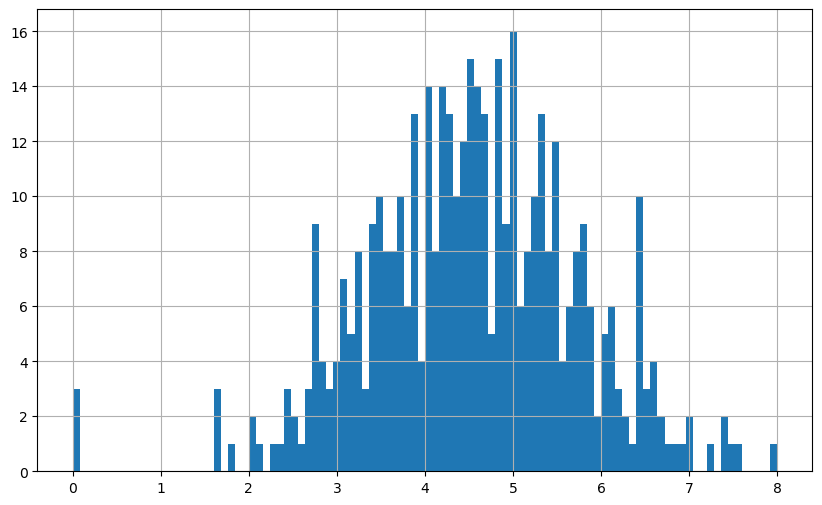

In [7]:
df_result_2022['average_severity'].hist(figsize=(10, 6),bins=100)

<Axes: >

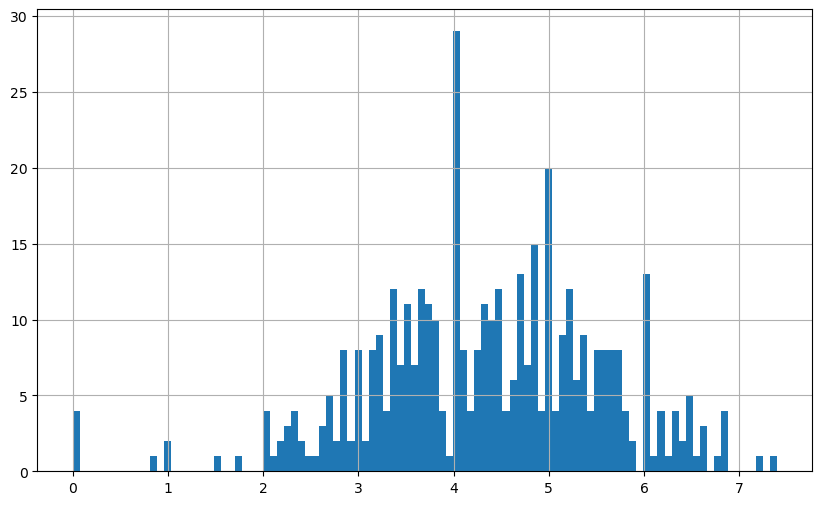

In [8]:
df_result_2023['average_severity'].hist(figsize=(10, 6),bins=100)

<Axes: >

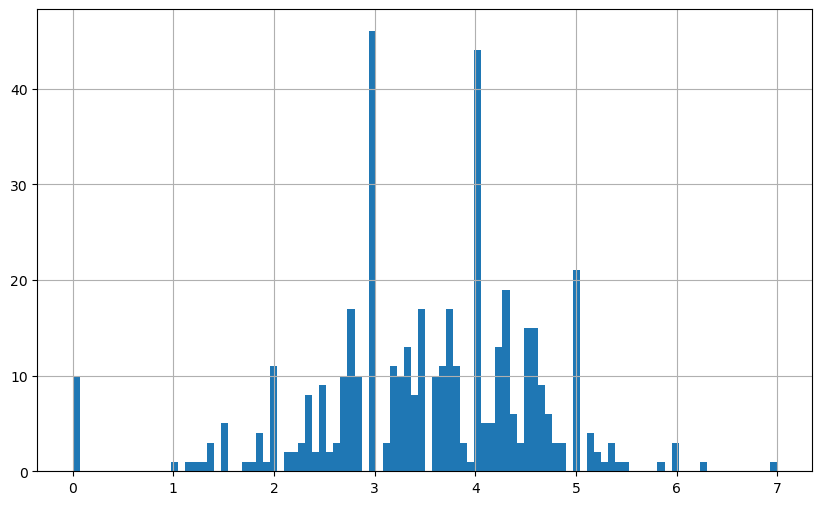

In [9]:
df_result_2024['average_severity'].hist(figsize=(10, 6),bins=100)

In [10]:
df_result_2021[df_result_2021['average_severity'] < 2].sort_values(by='calculated_score', ascending=False)

,company_name,date,calculated_score,average_severity,number_of_evidence,holistic_analysis
614,EXR,2021-02-26,25,1.666667,15,EXR’s 2021 Form 10-K squarely acknowledges COV...
1611,VRSK,2021-02-23,21,1.909091,11,VRSK’s 2021 Form 10-K provides a relatively da...
1598,USB,2021-02-23,0,0.000000,0,A meticulous review of the supplied filing tex...
1670,WFC,2021-02-23,0,0.000000,0,"The provided excerpt from WFC’s February 23, 2..."


In [11]:
df_snippet_score = pd.DataFrame(columns=['company_name', 'date', 'number_of_evidence', 'evidence_no', 'final_snippet_score'])

for f_p in tqdm(result_paths):
    with open(f_p, 'r', encoding='utf-8') as f:
        result = json.load(f)[0]
    
    company_name = f_p.split('/')[-1].split('_')[0]
    date = f_p.split('/')[-1].split('_')[1].split('.')[0]
    evidence_list = result['evidence_list']
    number_of_evidence = len(evidence_list)
    for i, evidence in enumerate(evidence_list):
        evidence_no = i + 1
        final_snippet_score = evidence['score_calculation']['final_snippet_score']
        df_snippet_score.loc[len(df_snippet_score)] = [company_name, date, number_of_evidence, evidence_no, final_snippet_score]

df_snippet_score.to_csv('./Result/llm_result/snippet_score.csv', index=False, encoding='utf-8-sig')
df_snippet_score

100%|██████████| 1728/1728 [00:05<00:00, 315.23it/s]


,company_name,date,number_of_evidence,evidence_no,final_snippet_score
0,AAPL,2021-10-29,18,1,6
1,AAPL,2021-10-29,18,2,3
2,AAPL,2021-10-29,18,3,3
3,AAPL,2021-10-29,18,4,3
4,AAPL,2021-10-29,18,5,5
...,...,...,...,...,...
16436,ZTS,2024-02-13,5,1,3
16437,ZTS,2024-02-13,5,2,2
16438,ZTS,2024-02-13,5,3,3
16439,ZTS,2024-02-13,5,4,4


<Axes: >

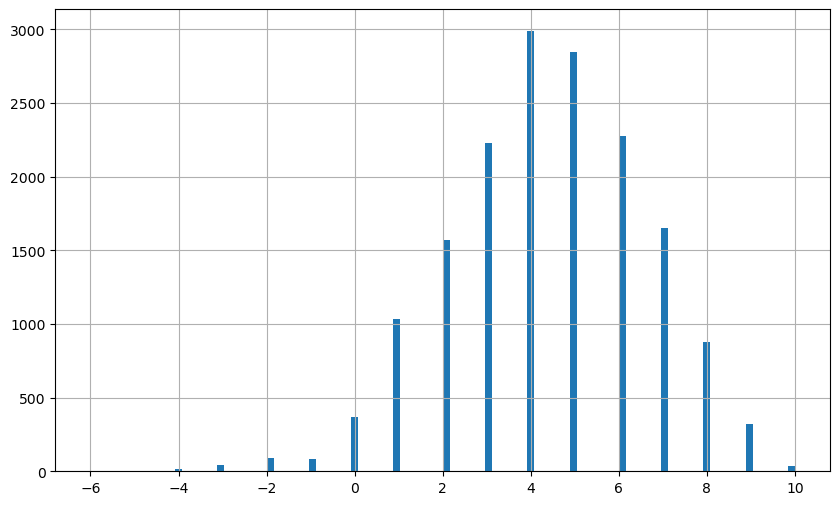

In [12]:
df_snippet_score['final_snippet_score'].hist(figsize=(10, 6), bins=100)

In [13]:
df_snippet_score[df_snippet_score['final_snippet_score'] == -5]

,company_name,date,number_of_evidence,evidence_no,final_snippet_score
818,AMCR,2022-08-18,23,12,-5
1769,BALL,2023-02-21,8,3,-5
2729,CE,2021-02-11,14,10,-5
9856,MCO,2023-02-15,8,7,-5
14025,TDY,2021-02-26,8,6,-5


In [ ]:
y = alpha + b0*MKT + b1*SMB + b2*HML + e
y = alpha + b0*MKT + b1*SMB + b2*HML + b3 * COVID + e